# ALBEF Model Test Results — BNS/NSBH Classification

Results from: `Model/eval_results/bns_nsbh_test_v8/eval_results.json`

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

In [2]:
import os
_BASE = os.environ.get('BASE_DIR', '/fred/oz016/bgao_kn')

EVAL_DIR = Path('../Model/eval_results/bns_nsbh_test_v8')
OUT_DIR = Path(f"{_BASE}/gw-kn-multimodal/figures")
SAVE_DIR = OUT_DIR / "test_results"  # save plots alongside results


with open(EVAL_DIR / 'eval_results.json') as f:
    results = json.load(f)

print(json.dumps(results['classification_by_source'], indent=2))

{
  "bns": {
    "metrics": {
      "auroc": 0.9643514156341553,
      "auprc": 0.9058905211794019,
      "f1_optimal": 0.8642857074737549,
      "f1_threshold": 0.6100000143051147,
      "ece": 0.052883612443642265,
      "tp": 2776,
      "fp": 686,
      "tn": 5670,
      "fn": 234,
      "accuracy": 0.9017723681400811,
      "precision": 0.8018486424032352,
      "recall": 0.9222591362126246,
      "f1": 0.8578491965389369,
      "precision_confusion": 0.8018486424032352,
      "recall_confusion": 0.9222591362126246,
      "f1_confusion": 0.8578491965389369
    },
    "pair_type_counts": {
      "n_total": 9366,
      "n_positive": 3010,
      "n_optical_neg": 3010,
      "n_gw_neg": 268,
      "n_hard_neg": 3078
    }
  },
  "nsbh": {
    "metrics": {
      "auroc": 0.9449318051338196,
      "auprc": 0.7642893498675187,
      "f1_optimal": 0.7334811091423035,
      "f1_threshold": 0.7099999785423279,
      "ece": 0.14246400053079386,
      "tp": 1865,
      "fp": 1425,
      "tn":

## Confusion Matrices — BNS and NSBH

In [3]:
def plot_confusion_matrix(
    ax, tp, fp, tn, fn,
    title, metrics=None,
    cmap='Blues', normalize=True
):
    """
    Plot a 2x2 confusion matrix on ax.

    Layout (scikit-learn convention):
        rows = actual label, cols = predicted label
        [[TN, FP],
         [FN, TP]]
    """
    cm_raw = np.array([[tn, fp],
                        [fn, tp]], dtype=float)

    if normalize:
        row_sums = cm_raw.sum(axis=1, keepdims=True)
        cm_plot = cm_raw / row_sums
    else:
        cm_plot = cm_raw

    im = ax.imshow(cm_plot, interpolation='nearest', cmap=cmap,
                   vmin=0, vmax=1 if normalize else None)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    labels = ['Negative', 'Positive']
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Predicted label', fontsize=12)
    ax.set_ylabel('True label', fontsize=12)

    thresh = cm_plot.max() / 2.0
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            val = cm_plot[i, j]
            raw = int(cm_raw[i, j])
            pct_str = f'{val:.1%}' if normalize else ''
            txt = f'{cell_labels[i][j]}\n{raw:,}'
            if normalize:
                txt += f'\n({pct_str})'
            color = 'white' if val > thresh else 'black'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=11, color=color, fontweight='bold')

    subtitle = ''
    if metrics is not None:
        prec = metrics.get('precision_confusion', metrics['tp'] / (metrics['tp'] + metrics['fp']))
        rec  = metrics.get('recall_confusion',    metrics['tp'] / (metrics['tp'] + metrics['fn']))
        f1   = metrics.get('f1_confusion',        2 * prec * rec / (prec + rec))
        auroc = metrics['auroc']
        # subtitle = (f'AUROC={auroc:.3f}  |  '
        #             f'Precision={prec:.3f}  |  '
        #             f'Recall={rec:.3f}  |  '
        #             f'F1={f1:.3f}')

    full_title = title
    if subtitle:
        full_title += f'\n{subtitle}'
    ax.set_title(full_title, fontsize=13, pad=10)


Saved → /fred/oz016/bgao_kn/gw-kn-multimodal/figures/test_results/confusion_matrix_bns_nsbh.png


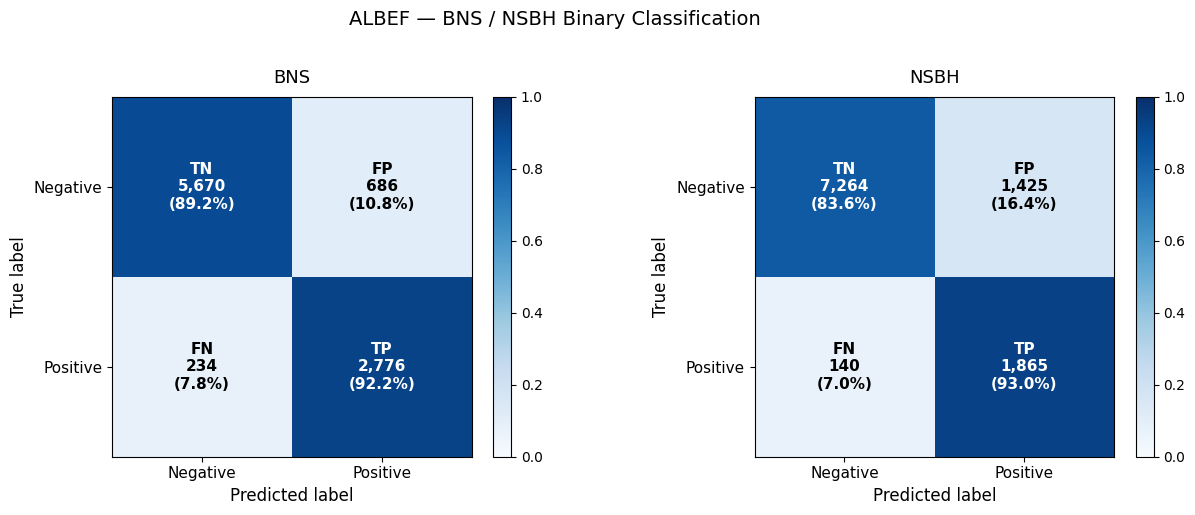

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ALBEF — BNS / NSBH Binary Classification',
             fontsize=14, y=1.02)

for ax, source in zip(axes, ['bns', 'nsbh']):
    m = results['classification_by_source'][source]['metrics']
    plot_confusion_matrix(
        ax,
        tp=m['tp'], fp=m['fp'], tn=m['tn'], fn=m['fn'],
        title=source.upper(),
        metrics=m,
        normalize=True,
    )

plt.tight_layout()
save_path = SAVE_DIR / 'confusion_matrix_bns_nsbh.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## Combined overview — all pairs

Saved → /fred/oz016/bgao_kn/gw-kn-multimodal/figures/test_results/confusion_matrix_all.png


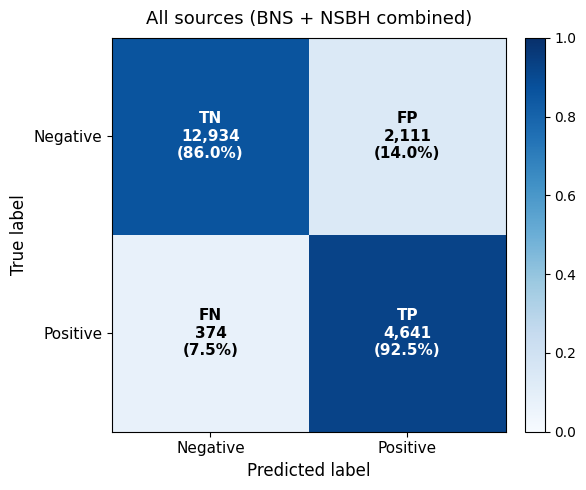

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

m = results['classification']
plot_confusion_matrix(
    ax,
    tp=m['tp'], fp=m['fp'], tn=m['tn'], fn=m['fn'],
    title='All sources (BNS + NSBH combined)',
    metrics=m,
    normalize=True,
)

plt.tight_layout()
save_path = SAVE_DIR / 'confusion_matrix_all.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()